## Task 4d: 'Haunted Places Witness Count'

In this notebook, we are adding a new feature called **“Haunted Places Witness Count”** that extracts the number of witnesses mentioned in the **description** of each haunted place.

We use the Python library **number-parser** (link: https://github.com/scrapinghub/number) to identify and extract numerical values from the text, specifically looking for references to the number of people who witnessed a supernatural event. If a valid number is found, it is stored in the new column. If no witness count is mentioned, we set the default value to **0** to maintain consistency in the dataset.

In [1]:
!pip install number-parser

In [12]:
import pandas as pd
import numpy as np
from number_parser import parse
from number_parser import parse_number
import re
import matplotlib.pyplot as plt


In [14]:
haunted_places = pd.read_csv("../data/haunted_places.tsv", sep='\t')

In [16]:
def extract_witness_count(description):
    text = description.lower()
    match_count = 0
    num_text = parse(text)
    strict_matches = re.findall(r'(\d+\s*(?:people|witnesses|individuals|sisters|students|civilians|teachers|eyewitnesses|employees|workers|teens|teenagers))', num_text)
    if strict_matches:
        for match in strict_matches:
            number_text = match[0]
            match_count += int(number_text)
        return match_count
    witnesses = re.findall(r'(people|witnesses|individuals|sisters|students|civilians|teachers|eyewitnesses|employees|workers|teens|teenagers|crowd)', num_text)
    for witness in witnesses:
        match_count += 2
    witnessed = re.search(r'(seen|saw|heard|reported|witnessed)', num_text)
    if witnessed:
        if match_count > 0:
            return match_count
        else:
            return 1
    return 0
        

In [18]:
haunted_places['Haunted Places Witness Count'] = haunted_places['description'].apply(extract_witness_count)

In [19]:
haunted_places.to_csv("../data/haunted_places.tsv", sep='\t', index=False)

In [49]:
# Load the dataset
haunted_places = pd.read_csv("../data/haunted_places.tsv", sep='\t')

# Get the list of current columns
columns = list(haunted_places.columns)

# Ensure there are at least 13 columns before inserting
if "Haunted Places Witness Count" in columns and len(columns) >= 13:
    # Remove the column from its current position
    columns.remove("Haunted Places Witness Count")
    # Insert it at position 13 (index 12 because Python uses 0-based indexing)
    columns.insert(13, "Haunted Places Witness Count")
    
    # Reorder the dataframe
    haunted_places = haunted_places[columns]

# Save the updated dataset
haunted_places.to_csv("../data/haunted_places.tsv", sep='\t', index=False)


## Visualization #1: Distribution of Haunted Places by Witness Count

This histogram visualizes the **distribution of haunted places based on the number of reported witnesses**.

Key insights from this visualization:
- It helps us understand **how frequently haunted events were observed by multiple individuals** versus being reported by a single person.
- The distribution reveals whether **most hauntings are solo experiences** or if there are cases where multiple people claim to have witnessed the same supernatural occurrence.
- If a significant number of reports have **zero witnesses**, it could indicate that many hauntings are based on folklore or secondhand accounts rather than direct observations.

By leveraging **number-parser**, we extract numerical witness data from the descriptions and use it to analyze trends in eyewitness reports. This analysis provides insight into the **credibility and frequency of haunted reports**, shedding light on whether hauntings are often collective experiences or isolated incidents.


In [21]:
# Count the number of entries with witness count = 0 and witness count > 0
zero_witness_count = (haunted_places['Haunted Places Witness Count'] == 0).sum()
non_zero_witness_count = (haunted_places['Haunted Places Witness Count'] > 0).sum()

# Calculate percentages
total = len(haunted_places)
zero_witness_percentage = (zero_witness_count / total) * 100
non_zero_witness_percentage = (non_zero_witness_count / total) * 100

# Print the results
print(f"Number of entries with witness count = 0: {zero_witness_count} ({zero_witness_percentage:.2f}%)")
print(f"Number of entries with witness count > 0: {non_zero_witness_count} ({non_zero_witness_percentage:.2f}%)")

Number of entries with witness count = 0: 6005 (54.63%)
Number of entries with witness count > 0: 4987 (45.37%)


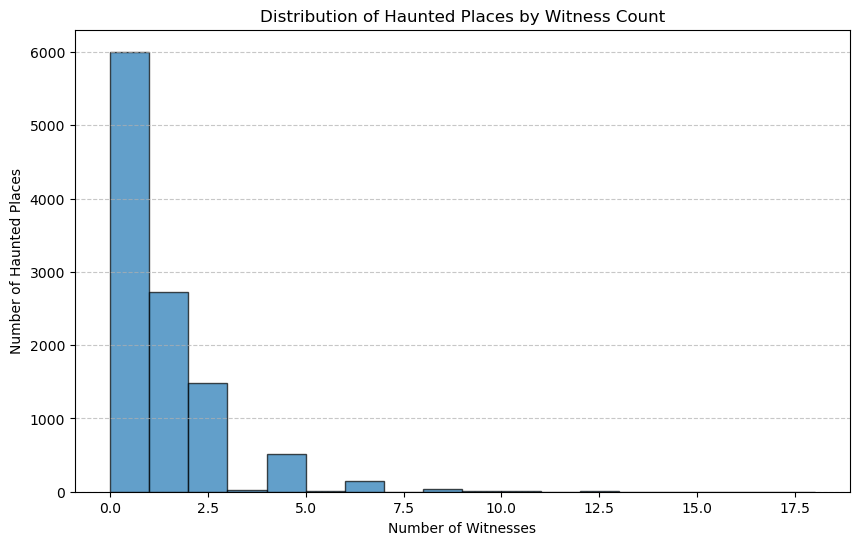

In [27]:

# Load the dataset (Update the file path to match your local setup)
haunted_places = pd.read_csv("../data/haunted_places.tsv", sep='\t')

# Ensure the column is numeric
haunted_places['Haunted Places Witness Count'] = pd.to_numeric(haunted_places['Haunted Places Witness Count'], errors="coerce").fillna(0).astype(int)

# Plot 1: Distribution of Haunted Places by Witness Count
plt.figure(figsize=(10, 6))
plt.hist(haunted_places["Haunted Places Witness Count"], bins=range(0, haunted_places["Haunted Places Witness Count"].max() + 1, 1),
         edgecolor="black", alpha=0.7)
plt.xlabel("Number of Witnesses")
plt.ylabel("Number of Haunted Places")
plt.title("Distribution of Haunted Places by Witness Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Visualization #2: Average Witness Count by State

- The second visualization will highlight **Average Witness Count by State** which analyzes the **average number of witnesses per state** for haunted places.

This bar chart helps us identify:
- Which states have the highest average witness counts for haunted events.
- Regional trends in supernatural sightings—do some states report more group-witnessed hauntings than others?
- The distribution of witness reports across different states, providing insights into where haunted events tend to be observed by multiple people.

By aggregating the data at the state level, we can better understand patterns in witness reports rather than focusing on individual cases. This approach allows us to determine if **certain states consistently report more haunted events with multiple witnesses**.

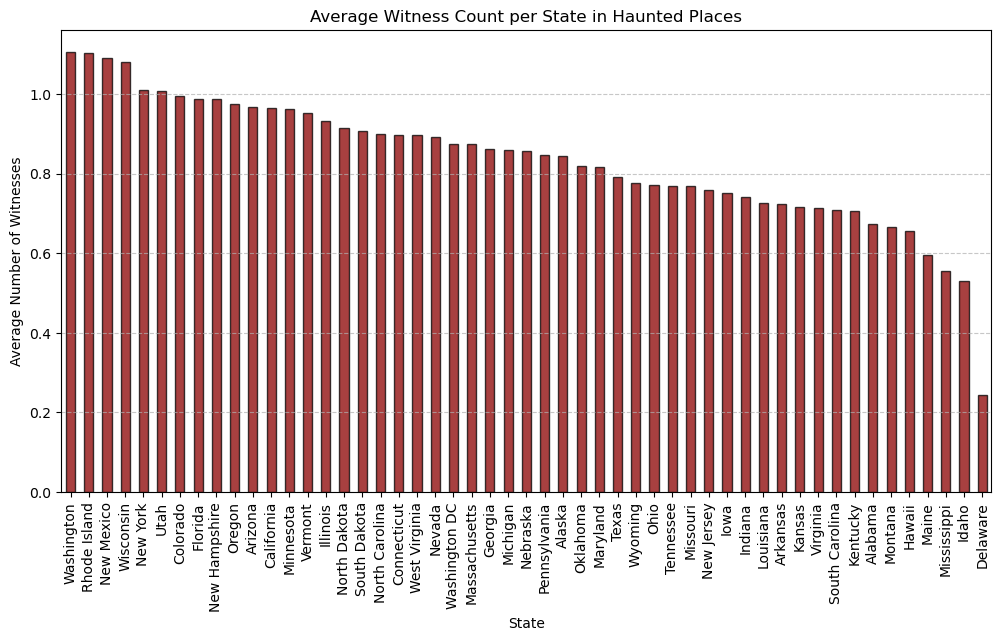

In [34]:
# Group by state and calculate the average witness count
state_witness_avg = haunted_places.groupby("state")["Haunted Places Witness Count"].mean().sort_values(ascending=False)

# Plot: Average Witness Count per State
plt.figure(figsize=(12, 6))
state_witness_avg.plot(kind="bar", color="darkred", alpha=0.75, edgecolor="black")
plt.xlabel("State")
plt.ylabel("Average Number of Witnesses")
plt.title("Average Witness Count per State in Haunted Places")
plt.xticks(rotation=90)  # Rotate state labels for readability
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()
